In [1]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, stats
from datetime import datetime, timedelta
import datajoint as dj
from scipy.ndimage import gaussian_filter
import bottleneck as bn
from matplotlib.colors import LogNorm
from matplotlib.patches import Patch
import plotly.io as pio
from diptest import diptest

c:\Users\Organoid PC\anaconda3\envs\utah_organoids\lib\site-packages\datajoint\plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
dj.config.load("dj_local_conf_worker.json")
dj.conn()

[2026-04-08 13:48:53,122][INFO]: DataJoint is configured from c:\Users\Organoid PC\Documents\GitHub\utah_organoids\dj_local_conf_worker.json
[2026-04-08 13:48:53,534][INFO]: DataJoint 0.14.8 connected to utah-worker@db.datajoint.com:3306


DataJoint connection (connected) utah-worker@db.datajoint.com:3306

In [4]:
from element_array_ephys.ephys_no_curation import map_channel_to_electrode
from workflow.pipeline import frame, culture, ephys, analysis, mua, probe

Module stfio is not installed. Make sure .abf files are converted to .pkl in Python 2.


In [5]:
organoid_id = "O09"
drug_name = "Control"

exp_key = {
    "organoid_id": organoid_id,
    "experiment_start_time": (culture.Experiment & f"organoid_id = '{organoid_id}'" & f"drug_name = '{drug_name}'").fetch1("experiment_start_time"),
}

culture.Experiment & exp_key

organoid_id e.g. O17,experiment_start_time,experiment_end_time,user,lineage_id de-identified code (e.g. hmau001),induction_culture_date,induction_culture_plate,post_induction_culture_date,post_induction_culture_plate,isolated_rosette_culture_date Date for isolating the rosette,isolated_rosette_culture_plate,organoid_culture_date,organoid_culture_plate,drug_name,drug_concentration concentration in uM,"experiment_plan e.g. mrna lysate, oct, protein lysate, or matrigel embedding, ephys, tracing"
O09,2023-05-03 17:33:00,2023-05-18 12:15:00,None,None,None,None,None,None,None,None,None,None,Control,nan,ephys


In [6]:
experiment_start_time, experiment_end_time = (culture.Experiment & exp_key).fetch1("experiment_start_time", "experiment_end_time") 

In [7]:
ephys_file_keys = (ephys.EphysRawFile & f"file_time BETWEEN '{experiment_start_time}' AND '{experiment_end_time}'").fetch("KEY")

In [9]:
keys = [
    {
        **exp_key,
        **file_key,
    }
    for file_key in ephys_file_keys
]

In [10]:
analysis.LongitudinalSpectralAnalysis.populate(keys[:500], display_progress=True)

LongitudinalSpectralAnalysis: 100%|██████████| 60/60 [09:04<00:00,  9.08s/it]


{'success_count': 60, 'error_list': []}

In [19]:
keys_per_iteration = 1000

for i in range(0, len(keys), keys_per_iteration):
    print(f"Processing keys {i} to {i+keys_per_iteration}...")

    if i + keys_per_iteration > len(keys):
        keys_subset = keys[i:]
    else:
        keys_subset = keys[i:i+keys_per_iteration]

    analysis.LongitudinalSpectralAnalysis.populate(keys_subset, display_progress=True)

[2026-04-07 09:12:07,563][WARNING]: Reconnecting to MySQL server.


Processing keys 0 to 1000...
Processing keys 1000 to 2000...
Processing keys 2000 to 3000...
Processing keys 3000 to 4000...
Processing keys 4000 to 5000...
Processing keys 5000 to 6000...
Processing keys 6000 to 7000...
Processing keys 7000 to 8000...
Processing keys 8000 to 9000...
Processing keys 9000 to 10000...
Processing keys 10000 to 11000...
Processing keys 11000 to 12000...
Processing keys 12000 to 13000...
Processing keys 13000 to 14000...


LongitudinalSpectralAnalysis: 100%|██████████| 942/942 [2:10:32<00:00,  8.31s/it]  


Processing keys 14000 to 15000...


LongitudinalSpectralAnalysis: 100%|██████████| 1000/1000 [2:24:57<00:00,  8.70s/it] 


...

LongitudinalSpectralAnalysis: 100%|██████████| 1000/1000 [2:24:17<00:00,  8.66s/it] 


Processing keys 19000 to 20000...


LongitudinalSpectralAnalysis: 100%|██████████| 1000/1000 [2:19:10<00:00,  8.35s/it] 


Processing keys 20000 to 21000...


LongitudinalSpectralAnalysis: 100%|██████████| 612/612 [1:25:14<00:00,  8.36s/it]


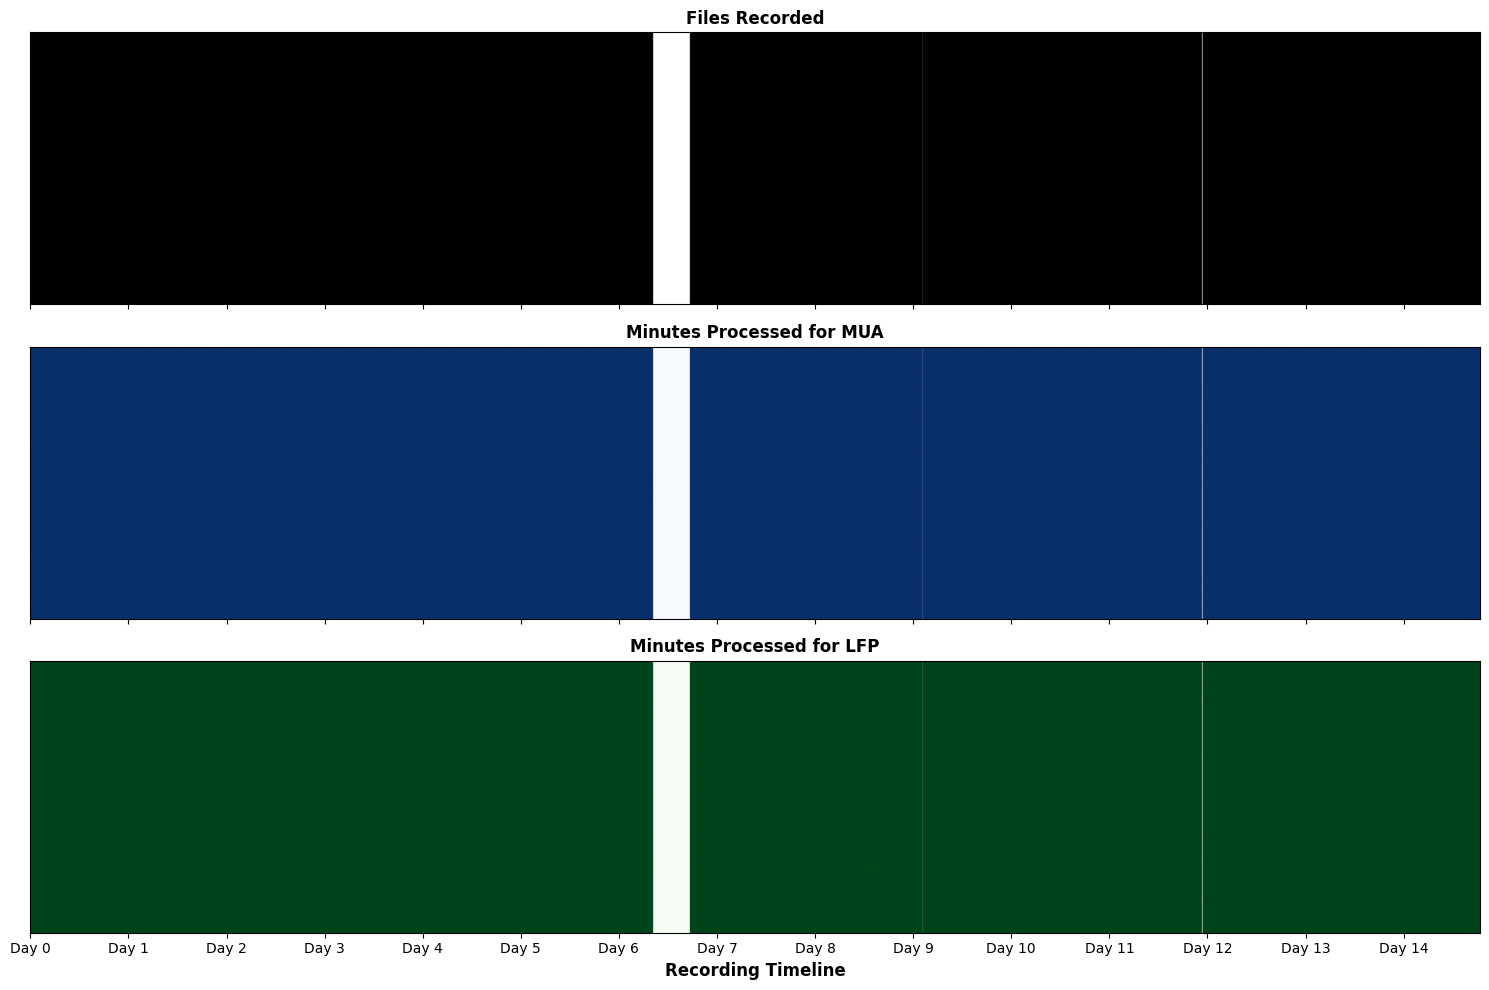

In [19]:
# Asses the recording timeline (how long were we recording? How many files do we have? How many of them are processed?)

# determine the experiment boundaries (based on exp_key)
experiment_start_time, experiment_end_time = (culture.Experiment & exp_key).fetch1("experiment_start_time", "experiment_end_time")

# find the available files within the experiment boundaries
file_times = (ephys.EphysRawFile & exp_key & f"file_time >= '{experiment_start_time}' AND file_time < '{experiment_end_time}'").fetch("file_time", order_by="file_time")

# get all times of the recording and the files that were recorded
minutes_recorded = file_times.astype("datetime64[m]")
recording_timeline = np.arange(minutes_recorded.min(), minutes_recorded.max(), dtype="datetime64[m]")

# get minutes processed (both mua and lfp)
processed_mua_minutes = (mua.MUAEphysSession & exp_key).fetch("start_time", order_by="start_time").astype("datetime64[m]")
processed_lfp_minutes = (analysis.LongitudinalSpectralAnalysis * ephys.EphysRawFile & exp_key).fetch("file_time", order_by="file_time").astype("datetime64[m]")

# Create a 3x1 plot (each are boolean image plots) showing the files recorded, the minutes processed for mua, and the minutes processed for lfp. 
# The x-axis should be the recording timeline (from experiment start to end) and 
# the y-axis should just be a boolean value (1 or 0) indicating whether there was a file recorded/processed at that minute or not.

fig, axs = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
axs[0].imshow(np.isin(recording_timeline, minutes_recorded)[None, :], aspect="auto", cmap="Greys", vmin=0, vmax=1)
axs[0].set_title("Files Recorded", fontsize=12, fontweight="bold")
axs[0].set_yticks([])

axs[1].imshow(np.isin(recording_timeline, processed_mua_minutes)[None, :], aspect="auto", cmap="Blues", vmin=0, vmax=1)
axs[1].set_title("Minutes Processed for MUA", fontsize=12, fontweight="bold")
axs[1].set_yticks([])

axs[2].imshow(np.isin(recording_timeline, processed_lfp_minutes)[None, :], aspect="auto", cmap="Greens", vmin=0, vmax=1)
axs[2].set_title("Minutes Processed for LFP", fontsize=12, fontweight="bold")
axs[2].set_yticks([])

# create xticks and labels
dt = 1 # days
minutes_since_start = (recording_timeline - recording_timeline[0]) / np.timedelta64(1, "m")
xticks = np.arange(0, minutes_since_start.max(), 60*24*dt)
xtick_labels = [f"Day {int(x/(60*24))}" for x in xticks]

plt.xlabel("Recording Timeline", fontsize=12, fontweight="bold")
plt.xticks(xticks, xtick_labels)

plt.tight_layout()
plt.show()

In [37]:
frequency_bands = {
    band['band_name']: (band['lower_freq'], band['upper_freq']) for band in analysis.SpectralBand.fetch(as_dict=True, order_by='lower_freq')
    }

band_colors = {
    "delta": "#ad2bea",
    "theta": "#4d3ff8",
    "alpha": "#39cabb",
    "beta": "#53e53a",
    "gamma": "#e3e12c",
    "highgamma1": "#f7a740",
    "highgamma2": "#ed3838",
}

greek_letters = {
    "delta": "\u03B4",
    "theta": "\u03B8",
    "alpha": "\u03B1",
    "beta": "\u03B2",
    "gamma": "\u03B3",
    "highgamma1": "\u03B3\u2081", 
    "highgamma2": "\u03B3\u2082",  
}

[2026-04-08 18:03:18,851][WARNING]: Reconnecting to MySQL server.


In [116]:
import bottleneck as bn
from scipy.ndimage import gaussian_filter1d

In [129]:
# get average frequency band power (z-scored) across entire recording
# DOES NOT ACCOUNT FOR ELECTRODES OUTSIDE OF ORGANOID

# fetch data
band_names, band_powers = (analysis.LongitudinalSpectralAnalysis.BandPower * ephys.EphysRawFile & exp_key).fetch("band_name", "band_power", order_by="file_time")
lfp_file_times = (analysis.LongitudinalSpectralAnalysis * ephys.EphysRawFile & exp_key).fetch("file_time", order_by="file_time")

# average across electrodes
mean_band_power = np.mean(np.stack(band_powers), axis=1) # average across electrodes

# stack data per frequency band (time x bands)
power_array = np.array([mean_band_power[band_names == band_name] for band_name in frequency_bands.keys()]).T

# z-score across time for each frequency band (normalized for total power)
power_z_scores = stats.zscore(power_array / power_array.sum(axis=1, keepdims=True), axis=0)

# get population firing rate
mua_file_times, population_firing_rate = dj.U("start_time").aggr(
    (mua.MUASpikes.Channel & exp_key),
    pop_spike_rate = 'sum(spike_rate)'
).fetch("start_time", "pop_spike_rate", order_by="start_time")

# filter data
gaus_len_min = 5
truncate = 4

power_z_scores = gaussian_filter1d(power_z_scores, sigma=gaus_len_min, truncate=truncate, axis=0, mode="reflect")
population_firing_rate = gaussian_filter1d(population_firing_rate.astype("float32"), sigma=gaus_len_min, truncate=truncate, mode="reflect")

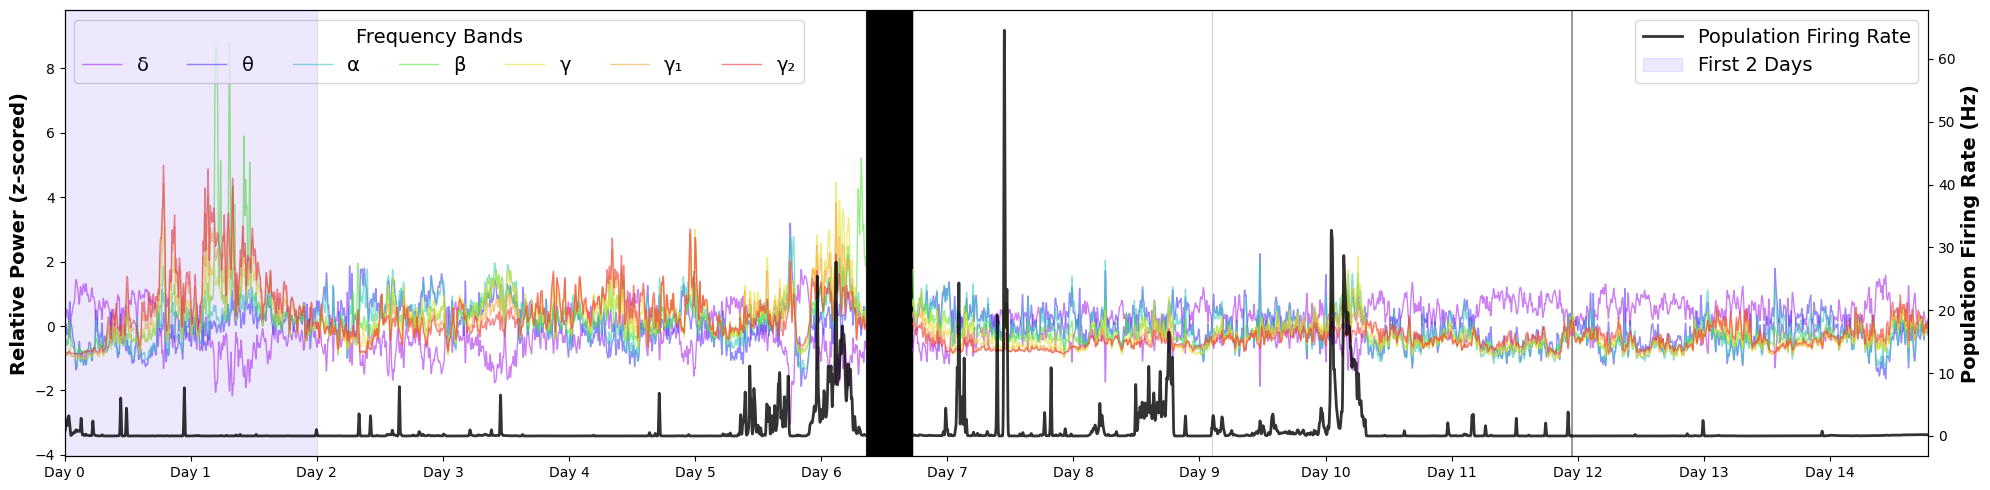

In [131]:
# determine which minutes have been processed
experiment_start_time, experiment_end_time = (culture.Experiment & exp_key).fetch1("experiment_start_time", "experiment_end_time")
recording_timeline = np.arange(np.datetime64(experiment_start_time, "m"), np.datetime64(experiment_end_time, "m"), dtype="datetime64[m]")

processed_mua_minutes = mua_file_times.astype("datetime64[m]")
processed_lfp_minutes = lfp_file_times.astype("datetime64[m]")
processed_minutes = np.intersect1d(processed_mua_minutes, processed_lfp_minutes)

# create an array that combines band powers and firing rate (NaN for unprocessed minutes)
combined_data = np.full((len(recording_timeline), power_z_scores.shape[1] + 1), np.nan) # +1 for firing rate

minutes_recorded = (processed_minutes - recording_timeline[0]).astype(int) # convert to indices relative to recording timeline
combined_data[minutes_recorded, :-1] = power_z_scores[np.isin(processed_lfp_minutes, processed_minutes)]
combined_data[minutes_recorded, -1] = population_firing_rate[np.isin(processed_mua_minutes, processed_minutes)]


# plot figure
# for periods that were not processed, plot a black background
# for periods that were processed plot band powers and population_firing_rate on the same plot (but different y-axes)

fig, ax1 = plt.subplots(figsize=(20, 5))

# plot black background for unprocessed periods
unprocessed_bool_array = np.isnan(combined_data).any(axis=1, keepdims=True).T
ax1.imshow(unprocessed_bool_array, aspect="auto", cmap="Greys", vmin=0, vmax=1, extent=[0, len(recording_timeline), -1000, 1000])

# plot band powers for processed periods
max_power = np.nanmax(combined_data[:, :-1]) + 1
min_power = np.nanmin(combined_data[:, :-1]) - 1
ax1.set_ylim(min_power, max_power)

relative_minutes = (recording_timeline - recording_timeline[0]).astype(int)
for i, band_name in enumerate(frequency_bands.keys()):
    ax1.plot(relative_minutes, combined_data[:, i], label=greek_letters[band_name], color=band_colors[band_name], linewidth=1, alpha=0.6)

ax1.set_ylabel("Relative Power (z-scored)", fontsize=14, fontweight="bold")
ax1.legend(loc="upper left", ncols=len(frequency_bands), title="Frequency Bands", title_fontsize=14, fontsize=14)

# create a second y-axis for population firing rate
ax2 = ax1.twinx()
ax2.plot(relative_minutes, combined_data[:, -1], label="Population Firing Rate", color="black", linewidth=2, alpha=0.8)
ax2.set_ylabel("Population Firing Rate (Hz)", fontsize=14, fontweight="bold")

xticks = np.arange(0, relative_minutes.max(), 60*24) # every day
xtick_labels = [f"Day {int(x/(60*24))}" for x in xticks]
plt.xticks(xticks, xtick_labels, fontsize=14)

# shade the first two days of recording
shade_color = "#5E27F5"
ax2.axvspan(0, 60*24*2, color=shade_color, alpha=0.1, label="First 2 Days")
ax2.legend(loc="upper right", fontsize=14)

plt.tight_layout()
plt.show()